# Datathon Passos Mágicos  
## Análise educacional e modelo preditivo de risco de defasagem

Este notebook analisa os dados do PEDE de 2022, 2023 e 2024, responde às principais perguntas do Datathon e desenvolve um modelo para estimar a probabilidade de um aluno entrar em situação de defasagem no ano seguinte.

### Objetivos

1. Avaliar a evolução dos indicadores educacionais e psicossociais.
2. Investigar relações entre IAN, IDA, IEG, IAA, IPS, IPP, IPV e INDE.
3. Verificar a efetividade do programa ao longo dos anos e fases.
4. Criar um modelo preditivo de risco de defasagem.
5. Gerar recomendações acionáveis para a Associação Passos Mágicos.

> **Nota metodológica:** sempre que possível, o modelo utiliza os indicadores do ano atual para prever a defasagem no ano seguinte. Isso reduz vazamento de informação e aproxima o experimento de um uso real.

## 1. Configuração do ambiente

In [7]:
# Caso esteja executando no Google Colab, descomente a linha abaixo:
# !pip install openpyxl -q

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Leitura da base

O código procura o arquivo no mesmo diretório do notebook e também no diretório padrão do Colab.

In [8]:
ARQUIVO = Path("BASE DE DADOS PEDE 2024 - DATATHON.xlsx")

caminhos_possiveis = [
    ARQUIVO,
    Path("/content") / ARQUIVO.name,
    Path("/mnt/data") / ARQUIVO.name
]

arquivo_encontrado = next((p for p in caminhos_possiveis if p.exists()), None)

if arquivo_encontrado is None:
    raise FileNotFoundError(
        "Arquivo não encontrado. Envie 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx' "
        "para o mesmo diretório do notebook."
    )

xls = pd.ExcelFile(arquivo_encontrado)
print("Arquivo:", arquivo_encontrado)
print("Abas:", xls.sheet_names)

bases_brutas = {
    2022: pd.read_excel(arquivo_encontrado, sheet_name="PEDE2022"),
    2023: pd.read_excel(arquivo_encontrado, sheet_name="PEDE2023"),
    2024: pd.read_excel(arquivo_encontrado, sheet_name="PEDE2024"),
}

for ano, df in bases_brutas.items():
    print(f"{ano}: {df.shape[0]:,} linhas e {df.shape[1]} colunas")

Arquivo: BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Abas: ['PEDE2022', 'PEDE2023', 'PEDE2024']
2022: 860 linhas e 42 colunas
2023: 1,014 linhas e 48 colunas
2024: 1,156 linhas e 50 colunas


## 3. Padronização e limpeza

Os nomes de algumas colunas mudam entre os anos. A função abaixo cria uma estrutura única, preservando apenas variáveis relevantes para a análise.

In [9]:
def normalizar_texto(valor):
    if pd.isna(valor):
        return np.nan
    texto = str(valor).strip()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto.upper()


def limpar_fase(valor):
    if pd.isna(valor):
        return np.nan

    texto = normalizar_texto(valor)

    if "ALFA" in texto:
        return "ALFA"

    # A base de 2024 possui alguns valores com informação adicional.
    match = re.search(r"(?:FASE\s*)?(\d+)", texto)
    if match:
        return f"FASE {int(match.group(1))}"

    return texto


def preparar_ano(df, ano):
    df = df.copy()

    mapa = {
        "Nome": "Nome_Anonimizado",
        "Nome Anonimizado": "Nome_Anonimizado",
        "Idade 22": "Idade",
        "Defas": "Defasagem",
        "Fase ideal": "Fase_Ideal",
        "Fase Ideal": "Fase_Ideal",
        "Instituição de ensino": "Instituicao",
        "Ano ingresso": "Ano_Ingresso",
        "Ano nasc": "Ano_Nascimento",
        "Data de Nasc": "Data_Nascimento",
        "Pedra 22": "Pedra_Atual" if ano == 2022 else "Pedra_22",
        "Pedra 2023": "Pedra_Atual" if ano == 2023 else "Pedra_2023",
        "Pedra 2024": "Pedra_Atual" if ano == 2024 else "Pedra_2024",
        "INDE 22": "INDE" if ano == 2022 else "INDE_22",
        "INDE 2023": "INDE" if ano == 2023 else "INDE_2023",
        "INDE 2024": "INDE" if ano == 2024 else "INDE_2024",
        "Matem": "Matematica",
        "Mat": "Matematica",
        "Portug": "Portugues",
        "Por": "Portugues",
        "Inglês": "Ingles",
        "Ing": "Ingles",
        "Atingiu PV": "Atingiu_PV",
        "Rec Psicologia": "Rec_Psicologia",
        "Ativo/ Inativo": "Status"
    }

    df = df.rename(columns=mapa)
    df["Ano"] = ano

    colunas = [
        "RA", "Ano", "Fase", "Turma", "Nome_Anonimizado", "Idade",
        "Gênero", "Ano_Ingresso", "Instituicao", "Pedra_Atual", "INDE",
        "IAA", "IEG", "IPS", "IPP", "IDA", "Matematica", "Portugues",
        "Ingles", "IPV", "IAN", "Fase_Ideal", "Defasagem",
        "Indicado", "Atingiu_PV", "Rec_Psicologia", "Status"
    ]

    for coluna in colunas:
        if coluna not in df.columns:
            df[coluna] = np.nan

    df = df[colunas]

    numericas = [
        "Ano", "Idade", "Ano_Ingresso", "INDE", "IAA", "IEG", "IPS",
        "IPP", "IDA", "Matematica", "Portugues", "Ingles", "IPV",
        "IAN", "Defasagem"
    ]

    for coluna in numericas:
        df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

    df["RA"] = df["RA"].astype(str).str.strip()
    df.loc[df["RA"].isin(["nan", "None", ""]), "RA"] = np.nan

    df["Fase_Original"] = df["Fase"]
    df["Fase"] = df["Fase"].apply(limpar_fase)

    for coluna in ["Gênero", "Instituicao", "Pedra_Atual", "Indicado",
                   "Atingiu_PV", "Status"]:
        df[coluna] = df[coluna].apply(normalizar_texto)

    return df


bases = {
    ano: preparar_ano(df, ano)
    for ano, df in bases_brutas.items()
}

dados = pd.concat(bases.values(), ignore_index=True)

print("Base consolidada:", dados.shape)
display(dados.head())

Base consolidada: (3030, 28)


,RA,Ano,Fase,Turma,Nome_Anonimizado,Idade,Gênero,Ano_Ingresso,Instituicao,Pedra_Atual,INDE,IAA,IEG,IPS,IPP,IDA,Matematica,Portugues,Ingles,IPV,IAN,Fase_Ideal,Defasagem,Indicado,Atingiu_PV,Rec_Psicologia,Status,Fase_Original
0,RA-1,2022,FASE 7,A,Aluno-1,19.000,MENINA,2016,ESCOLA PUBLICA,QUARTZO,5.783,8.300,4.100,5.600,NaN,4.000,2.700,3.500,6.000,7.278,5.000,Fase 8 (Universitários),-1,SIM,NAO,Requer avaliação,NaN,7
1,RA-2,2022,FASE 7,A,Aluno-2,17.000,MENINA,2017,REDE DECISAO,AMETISTA,7.055,8.800,5.200,6.300,NaN,6.800,6.300,4.500,9.700,6.778,10.000,Fase 7 (3º EM),0,NAO,NAO,Sem limitações,NaN,7
2,RA-3,2022,FASE 7,A,Aluno-3,17.000,MENINA,2016,REDE DECISAO,AGATA,6.591,0.000,7.900,5.600,NaN,5.600,5.800,4.000,6.900,7.556,10.000,Fase 7 (3º EM),0,NAO,NAO,Sem limitações,NaN,7
3,RA-4,2022,FASE 7,A,Aluno-4,17.000,MENINO,2017,REDE DECISAO,QUARTZO,5.951,8.800,4.500,5.600,NaN,5.000,2.800,3.500,8.700,5.278,10.000,Fase 7 (3º EM),0,NAO,NAO,Requer avaliação,NaN,7
4,RA-5,2022,FASE 7,A,Aluno-5,17.000,MENINA,2016,REDE DECISAO,AMETISTA,7.427,7.900,8.600,5.600,NaN,5.200,7.000,2.900,5.700,7.389,10.000,Fase 7 (3º EM),0,NAO,NAO,Requer avaliação,NaN,7


### 3.1 Validação da qualidade dos dados

In [10]:
resumo_qualidade = pd.DataFrame({
    "Tipo": dados.dtypes.astype(str),
    "Nulos": dados.isna().sum(),
    "% Nulos": dados.isna().mean().mul(100),
    "Únicos": dados.nunique(dropna=True)
}).sort_values("% Nulos", ascending=False)

display(resumo_qualidade)

print("Registros duplicados completos:", dados.duplicated().sum())
print("Duplicidades de aluno no mesmo ano:",
      dados.duplicated(subset=["RA", "Ano"]).sum())

# Mantém o último registro em raros casos de duplicidade RA/Ano.
dados = (
    dados.sort_values(["RA", "Ano"])
         .drop_duplicates(subset=["RA", "Ano"], keep="last")
         .reset_index(drop=True)
)

indicadores = ["INDE", "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV"]

# Valores fora de uma escala educacional plausível de 0 a 10 são tratados como ausentes.
for coluna in indicadores:
    dados.loc[~dados[coluna].between(0, 10, inclusive="both"), coluna] = np.nan

print("Dimensão após deduplicação:", dados.shape)

,Tipo,Nulos,% Nulos,Únicos
Rec_Psicologia,object,2170,71.617,5
Indicado,object,2170,71.617,2
Atingiu_PV,object,2170,71.617,2
Ingles,float64,1939,63.993,84
Status,object,1874,61.848,1
IPP,float64,1038,34.257,86
Idade,float64,399,13.168,20
Portugues,float64,185,6.106,87
INDE,float64,185,6.106,2708
Matematica,float64,184,6.073,83


Registros duplicados completos: 0
Duplicidades de aluno no mesmo ano: 0
Dimensão após deduplicação: (3030, 28)


## 4. Visão geral da população

In [11]:
resumo_ano = (
    dados.groupby("Ano")
    .agg(
        Alunos=("RA", "nunique"),
        Idade_Media=("Idade", "mean"),
        INDE_Medio=("INDE", "mean"),
        IDA_Medio=("IDA", "mean"),
        IEG_Medio=("IEG", "mean"),
        Defasagem_Media=("Defasagem", "mean")
    )
)

display(resumo_ano)

,Alunos,Idade_Media,INDE_Medio,IDA_Medio,IEG_Medio,Defasagem_Media
Ano,,,,,,
2022,860,12.138,7.036,6.093,7.891,-0.943
2023,1014,12.294,7.342,6.663,8.699,-0.655
2024,1156,12.988,7.397,6.351,7.375,-0.409


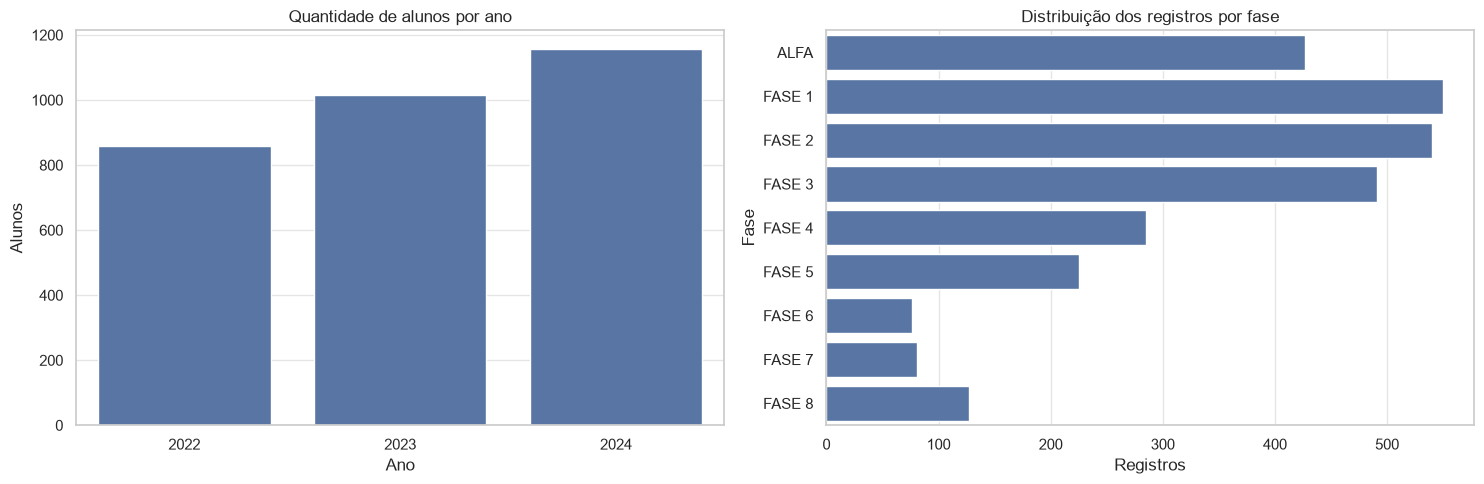

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=dados, x="Ano", ax=axes[0])
axes[0].set_title("Quantidade de alunos por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Alunos")

ordem_fases = ["ALFA"] + [f"FASE {i}" for i in range(1, 9)]
sns.countplot(
    data=dados,
    y="Fase",
    order=[f for f in ordem_fases if f in dados["Fase"].dropna().unique()],
    ax=axes[1]
)
axes[1].set_title("Distribuição dos registros por fase")
axes[1].set_xlabel("Registros")
axes[1].set_ylabel("Fase")

plt.tight_layout()
plt.show()

# 5. Respostas às perguntas do Datathon

## Pergunta 1 — Adequação do nível (IAN)

O IAN possui três níveis principais na base. Para facilitar a comunicação gerencial, eles são classificados em:

- **Adequado:** IAN = 10
- **Defasagem moderada:** IAN = 5
- **Defasagem severa:** IAN = 2,5

In [14]:
def classificar_ian(valor):
    if pd.isna(valor):
        return np.nan
    if valor >= 7.5:
        return "Adequado"
    if valor >= 5:
        return "Defasagem moderada"
    return "Defasagem severa"

dados["Nivel_IAN"] = dados["IAN"].apply(classificar_ian)

ian_ano = pd.crosstab(
    dados["Ano"],
    dados["Nivel_IAN"],
    normalize="index"
).mul(100)

display(ian_ano.round(2))

ian_contagem = pd.crosstab(dados["Ano"], dados["Nivel_IAN"])
display(ian_contagem)

Nivel_IAN,Adequado,Defasagem moderada,Defasagem severa
Ano,,,
2022,30.120,66.630,3.260
2023,45.560,53.060,1.380
2024,53.810,45.930,0.260


Nivel_IAN,Adequado,Defasagem moderada,Defasagem severa
Ano,,,
2022,259,573,28
2023,462,538,14
2024,622,531,3


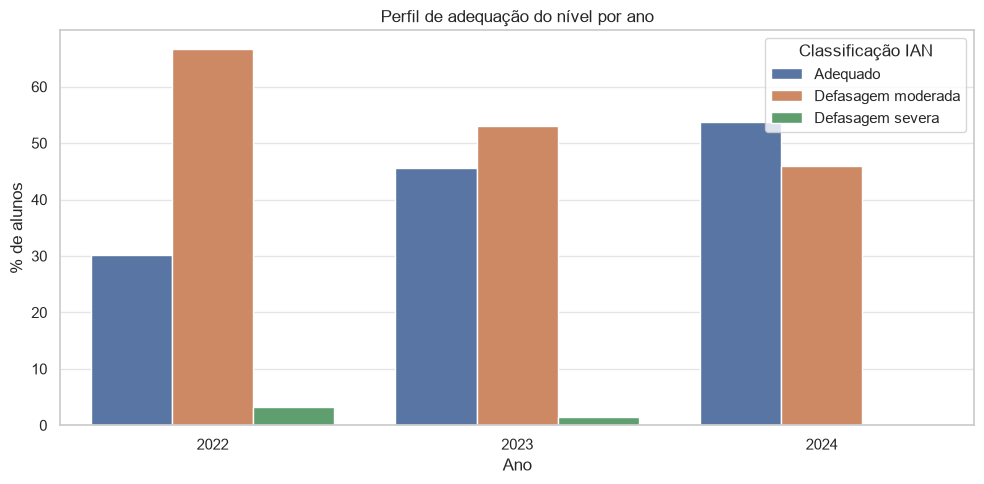

In [15]:
plt.figure(figsize=(10, 5))
ordem_ian = ["Adequado", "Defasagem moderada", "Defasagem severa"]

df_plot = (
    dados.groupby(["Ano", "Nivel_IAN"])
    .size()
    .reset_index(name="Quantidade")
)

df_plot["Percentual"] = (
    df_plot["Quantidade"] /
    df_plot.groupby("Ano")["Quantidade"].transform("sum")
) * 100

sns.barplot(
    data=df_plot,
    x="Ano",
    y="Percentual",
    hue="Nivel_IAN",
    hue_order=ordem_ian
)

plt.title("Perfil de adequação do nível por ano")
plt.ylabel("% de alunos")
plt.xlabel("Ano")
plt.legend(title="Classificação IAN")
plt.tight_layout()
plt.show()


In [16]:
# Evolução individual da defasagem entre anos consecutivos
painel_defas = dados.pivot_table(
    index="RA",
    columns="Ano",
    values="Defasagem",
    aggfunc="last"
)

transicoes = []

for ano_atual, ano_seguinte in [(2022, 2023), (2023, 2024)]:
    pares = painel_defas[[ano_atual, ano_seguinte]].dropna().copy()
    pares["Mudanca"] = pares[ano_seguinte] - pares[ano_atual]
    pares["Situacao"] = np.select(
    [
        pares["Mudanca"] < 0,
        pares["Mudanca"] == 0,
        pares["Mudanca"] > 0
    ],
    [
        "Piorou",
        "Permaneceu",
        "Melhorou"
    ],
    default="Sem classificação"
    )
    resumo = pares["Situacao"].value_counts().rename_axis("Situacao").reset_index(name="Alunos")
    resumo["Transicao"] = f"{ano_atual} → {ano_seguinte}"
    transicoes.append(resumo)

resumo_transicoes = pd.concat(transicoes, ignore_index=True)
display(resumo_transicoes)

,Situacao,Alunos,Transicao
0,Permaneceu,311,2022 → 2023
1,Melhorou,185,2022 → 2023
2,Piorou,104,2022 → 2023
3,Permaneceu,320,2023 → 2024
4,Melhorou,313,2023 → 2024
5,Piorou,132,2023 → 2024


## Pergunta 2 — Desempenho acadêmico (IDA)

A análise compara o IDA médio por ano e por fase, além de acompanhar alunos presentes em anos consecutivos.

In [ ]:
ida_ano = dados.groupby("Ano")["IDA"].agg(["count", "mean", "median", "std"])
display(ida_ano)

plt.figure(figsize=(9, 5))
sns.pointplot(data=dados, x="Ano", y="IDA", errorbar=("ci", 95), capsize=.1)
plt.ylim(0, 10)
plt.title("Evolução do IDA médio")
plt.ylabel("IDA médio")
plt.xlabel("Ano")
plt.tight_layout()
plt.show()

In [ ]:
ida_fase_ano = dados.pivot_table(
    index="Fase",
    columns="Ano",
    values="IDA",
    aggfunc="mean"
)

ida_fase_ano = ida_fase_ano.reindex(
    [f for f in ordem_fases if f in ida_fase_ano.index]
)

plt.figure(figsize=(10, 6))
sns.heatmap(ida_fase_ano, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=10)
plt.title("IDA médio por fase e ano")
plt.xlabel("Ano")
plt.ylabel("Fase")
plt.tight_layout()
plt.show()

In [ ]:
# Evolução do IDA para os mesmos alunos
painel_ida = dados.pivot_table(index="RA", columns="Ano", values="IDA", aggfunc="last")

for a, b in [(2022, 2023), (2023, 2024)]:
    pares = painel_ida[[a, b]].dropna()
    delta = pares[b] - pares[a]
    print(
        f"{a} → {b}: {len(delta)} alunos | "
        f"variação média = {delta.mean():.3f} | "
        f"% que melhorou = {(delta > 0).mean() * 100:.1f}%"
    )

## Pergunta 3 — Engajamento (IEG), desempenho (IDA) e ponto de virada (IPV)

In [ ]:
correlacoes_engajamento = dados[["IEG", "IDA", "IPV"]].corr(method="spearman")
display(correlacoes_engajamento)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=dados,
    x="IEG",
    y="IDA",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Engajamento × Desempenho")
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 10)

sns.regplot(
    data=dados,
    x="IEG",
    y="IPV",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("Engajamento × Ponto de virada")
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

## Pergunta 4 — Coerência da autoavaliação (IAA)

A diferença entre IAA e IDA é utilizada como uma medida simples de alinhamento:

- diferença próxima de zero: percepção coerente;
- diferença positiva: autoavaliação acima do desempenho;
- diferença negativa: autoavaliação abaixo do desempenho.

In [ ]:
dados["Gap_IAA_IDA"] = dados["IAA"] - dados["IDA"]

dados["Perfil_Autoavaliacao"] = pd.cut(
    dados["Gap_IAA_IDA"],
    bins=[-np.inf, -1, 1, np.inf],
    labels=["Subestima desempenho", "Coerente", "Superestima desempenho"]
)

autoavaliacao = (
    dados.groupby(["Ano", "Perfil_Autoavaliacao"], observed=False)
    .size()
    .groupby(level=0)
    .apply(lambda x: 100 * x / x.sum())
    .rename("Percentual")
    .reset_index()
)

display(autoavaliacao)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=dados, x="IDA", y="IAA", hue="Ano", alpha=.4, ax=axes[0])
axes[0].plot([0, 10], [0, 10], "--", color="black")
axes[0].set_title("Autoavaliação versus desempenho real")
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 10)

sns.boxplot(data=dados, x="Ano", y="Gap_IAA_IDA", ax=axes[1])
axes[1].axhline(0, ls="--", color="black")
axes[1].set_title("Diferença IAA − IDA")
axes[1].set_ylabel("Gap de autoavaliação")

plt.tight_layout()
plt.show()

## Pergunta 5 — Aspectos psicossociais (IPS)

Para avaliar antecedência temporal, o IPS de um ano é comparado à variação de IDA e IEG no ano seguinte para alunos presentes em ambos os períodos.

In [ ]:
def criar_pares_longitudinais(df, ano_atual, ano_seguinte):
    atual = df[df["Ano"] == ano_atual].copy()
    seguinte = df[df["Ano"] == ano_seguinte].copy()

    pares = atual.merge(
        seguinte,
        on="RA",
        how="inner",
        suffixes=("_atual", "_seguinte")
    )

    pares["Delta_IDA"] = pares["IDA_seguinte"] - pares["IDA_atual"]
    pares["Delta_IEG"] = pares["IEG_seguinte"] - pares["IEG_atual"]
    pares["Queda_IDA"] = (pares["Delta_IDA"] < 0).astype(int)
    pares["Queda_IEG"] = (pares["Delta_IEG"] < 0).astype(int)
    pares["Transicao"] = f"{ano_atual} → {ano_seguinte}"

    return pares

pares_22_23 = criar_pares_longitudinais(dados, 2022, 2023)
pares_23_24 = criar_pares_longitudinais(dados, 2023, 2024)
pares_long = pd.concat([pares_22_23, pares_23_24], ignore_index=True)

print("Pares longitudinais:", len(pares_long))

display(
    pares_long[["IPS_atual", "Delta_IDA", "Delta_IEG"]]
    .corr(method="spearman")
)

In [ ]:
pares_long["Faixa_IPS"] = pd.qcut(
    pares_long["IPS_atual"],
    q=4,
    duplicates="drop"
)

risco_ips = (
    pares_long.groupby("Faixa_IPS", observed=False)
    .agg(
        Alunos=("RA", "count"),
        Taxa_Queda_IDA=("Queda_IDA", "mean"),
        Taxa_Queda_IEG=("Queda_IEG", "mean"),
        Delta_IDA_Medio=("Delta_IDA", "mean"),
        Delta_IEG_Medio=("Delta_IEG", "mean")
    )
)

risco_ips[["Taxa_Queda_IDA", "Taxa_Queda_IEG"]] *= 100
display(risco_ips)

## Pergunta 6 — IPP versus IAN

O IPP está ausente em 2022, portanto a comparação se concentra em 2023 e 2024.

In [ ]:
ipp_ian = dados.dropna(subset=["IPP", "IAN"]).copy()

display(
    ipp_ian.groupby("Nivel_IAN")["IPP"]
    .agg(["count", "mean", "median", "std"])
    .reindex(ordem_ian)
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=ipp_ian, x="Nivel_IAN", y="IPP", order=ordem_ian)
plt.title("Avaliação psicopedagógica por nível de adequação")
plt.xlabel("Classificação IAN")
plt.ylabel("IPP")
plt.tight_layout()
plt.show()

print(
    "Correlação Spearman IPP × IAN:",
    round(ipp_ian[["IPP", "IAN"]].corr(method="spearman").iloc[0, 1], 3)
)

## Pergunta 7 — Variáveis que mais influenciam o IPV

Nesta etapa, um modelo de Random Forest é usado como ferramenta explicativa. A importância por permutação indica quanto o erro aumenta quando cada variável é embaralhada.

In [ ]:
features_ipv = ["IDA", "IEG", "IAA", "IPS", "IPP", "IAN", "Idade", "Fase"]
base_ipv = dados.dropna(subset=["IPV"]).copy()

X_ipv = base_ipv[features_ipv]
y_ipv = base_ipv["IPV"]

num_ipv = X_ipv.select_dtypes(include=np.number).columns.tolist()
cat_ipv = X_ipv.select_dtypes(exclude=np.number).columns.tolist()

pre_ipv = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_ipv),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_ipv)
])

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

modelo_ipv = Pipeline([
    ("preprocessamento", pre_ipv),
    ("modelo", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        min_samples_leaf=5,
        n_jobs=-1
    ))
])

X_train_ipv, X_test_ipv, y_train_ipv, y_test_ipv = train_test_split(
    X_ipv, y_ipv, test_size=.25, random_state=RANDOM_STATE
)

modelo_ipv.fit(X_train_ipv, y_train_ipv)
pred_ipv = modelo_ipv.predict(X_test_ipv)

print("MAE:", round(mean_absolute_error(y_test_ipv, pred_ipv), 3))
print("R²:", round(r2_score(y_test_ipv, pred_ipv), 3))

perm_ipv = permutation_importance(
    modelo_ipv,
    X_test_ipv,
    y_test_ipv,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2"
)

importancia_ipv = pd.DataFrame({
    "Variavel": X_test_ipv.columns,
    "Importancia": perm_ipv.importances_mean
}).sort_values("Importancia", ascending=False)

display(importancia_ipv)

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=importancia_ipv, x="Importancia", y="Variavel")
plt.title("Importância das variáveis para explicar o IPV")
plt.xlabel("Queda média no R² após permutação")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Pergunta 8 — Multidimensionalidade dos indicadores

A correlação mostra associação individual. Para compreender combinações, também é ajustado um modelo explicativo do INDE.

In [ ]:
cols_corr = ["INDE", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN"]
corr = dados[cols_corr].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlação entre indicadores")
plt.tight_layout()
plt.show()

In [ ]:
# Combinações de alto desempenho usando quartis
base_multi = dados.dropna(subset=["INDE", "IDA", "IEG", "IPS", "IPP"]).copy()

for col in ["IDA", "IEG", "IPS", "IPP"]:
    base_multi[f"{col}_Alto"] = (
        base_multi[col] >= base_multi[col].median()
    ).map({True: "Alto", False: "Baixo"})

combinacoes = (
    base_multi.groupby(
        ["IDA_Alto", "IEG_Alto", "IPS_Alto", "IPP_Alto"],
        observed=False
    )
    .agg(
        Alunos=("RA", "count"),
        INDE_Medio=("INDE", "mean")
    )
    .query("Alunos >= 10")
    .sort_values("INDE_Medio", ascending=False)
)

display(combinacoes.head(10))

# 6. Modelo preditivo de risco de defasagem

## 6.1 Definição da variável-alvo

Um aluno é considerado em risco no ano seguinte quando:

- sua **Defasagem no ano seguinte é menor que zero**, indicando que a fase cursada está abaixo da fase ideal.

As variáveis preditoras são medidas no ano anterior. A coluna `Defasagem` do ano atual não é usada como preditora principal, pois poderia dominar o modelo e reduzir a utilidade dos demais indicadores. Uma segunda execução pode incluí-la como cenário comparativo.

In [17]:
def criar_base_modelagem(df, incluir_defasagem_atual=False):
    pares = []

    for ano_atual, ano_seguinte in [(2022, 2023), (2023, 2024)]:
        atual = df[df["Ano"] == ano_atual].copy()
        futuro = df[df["Ano"] == ano_seguinte][
            ["RA", "Defasagem", "IAN"]
        ].copy()

        futuro = futuro.rename(columns={
            "Defasagem": "Defasagem_Futura",
            "IAN": "IAN_Futuro"
        })

        combinado = atual.merge(futuro, on="RA", how="inner")
        combinado["Ano_Referencia"] = ano_atual
        combinado["Risco_Defasagem"] = (
            combinado["Defasagem_Futura"] < 0
        ).astype(int)

        pares.append(combinado)

    modelagem = pd.concat(pares, ignore_index=True)

    features = [
        "Ano_Referencia", "Idade", "Ano_Ingresso", "Fase", "Gênero",
        "Instituicao", "Pedra_Atual", "INDE", "IAN", "IDA", "IEG",
        "IAA", "IPS", "IPP", "IPV", "Matematica", "Portugues", "Ingles"
    ]

    if incluir_defasagem_atual:
        features.append("Defasagem")

    features = [c for c in features if c in modelagem.columns]

    return modelagem, features


base_modelo, features_modelo = criar_base_modelagem(
    dados,
    incluir_defasagem_atual=False
)

print("Observações:", len(base_modelo))
print("Alunos únicos:", base_modelo["RA"].nunique())
print("Features:", features_modelo)
print("\nDistribuição da variável-alvo:")
display(
    base_modelo["Risco_Defasagem"]
    .value_counts()
    .rename(index={0: "Sem defasagem futura", 1: "Com defasagem futura"})
    .to_frame("Alunos")
)

print(
    "Taxa de risco:",
    f"{base_modelo['Risco_Defasagem'].mean() * 100:.1f}%"
)

Observações: 1365
Alunos únicos: 897
Features: ['Ano_Referencia', 'Idade', 'Ano_Ingresso', 'Fase', 'Gênero', 'Instituicao', 'Pedra_Atual', 'INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Matematica', 'Portugues', 'Ingles']

Distribuição da variável-alvo:


,Alunos
Risco_Defasagem,
Sem defasagem futura,691
Com defasagem futura,674


Taxa de risco: 49.4%


## 6.2 Separação temporal entre treino e teste

Para simular o uso real:

- **Treino:** indicadores de 2022 para prever 2023;
- **Teste:** indicadores de 2023 para prever 2024.

Essa validação é mais rigorosa que uma separação aleatória, pois avalia a capacidade de generalização para um período futuro.

In [18]:
treino = base_modelo[base_modelo["Ano_Referencia"] == 2022].copy()
teste = base_modelo[base_modelo["Ano_Referencia"] == 2023].copy()

X_train = treino[features_modelo]
y_train = treino["Risco_Defasagem"]

X_test = teste[features_modelo]
y_test = teste["Risco_Defasagem"]

print("Treino:", X_train.shape, "| Positivos:", int(y_train.sum()))
print("Teste:", X_test.shape, "| Positivos:", int(y_test.sum()))

Treino: (600, 18) | Positivos: 366
Teste: (765, 18) | Positivos: 308


## 6.3 Pré-processamento

- Variáveis numéricas: imputação pela mediana e padronização.
- Variáveis categóricas: imputação pela moda e one-hot encoding.
- O pré-processamento é encapsulado em um `Pipeline`, evitando vazamento entre treino e teste.

In [19]:
colunas_numericas = X_train.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X_train.select_dtypes(exclude=np.number).columns.tolist()

preprocessamento = ColumnTransformer(
    transformers=[
        ("numericas", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),

        ("categoricas", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas)
    ],
    remainder="drop"
)

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

Numéricas: ['Ano_Referencia', 'Idade', 'Ano_Ingresso', 'INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'Matematica', 'Portugues', 'Ingles']
Categóricas: ['Fase', 'Gênero', 'Instituicao', 'Pedra_Atual']


## 6.4 Comparação de modelos

São comparados três algoritmos:

1. Regressão Logística;
2. Random Forest;
3. Gradient Boosting.

Como o objetivo é identificar alunos em risco, **Recall**, **F1** e **ROC-AUC** têm prioridade sobre a acurácia isolada.

In [20]:
modelos = {
    "Regressão Logística": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    )
}

resultados = []
pipelines_treinados = {}

for nome, estimador in modelos.items():
    pipeline = Pipeline([
        ("preprocessamento", clone(preprocessamento)),
        ("modelo", estimador)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    prob = pipeline.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob)
    })

    pipelines_treinados[nome] = pipeline

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values(["ROC_AUC", "Recall"], ascending=False)
    .reset_index(drop=True)
)

display(resultados_df.style.format({
    "Acurácia": "{:.3f}",
    "Precisão": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}",
    "ROC_AUC": "{:.3f}"
}))

,Modelo,Acurácia,Precisão,Recall,F1,ROC_AUC
0,Random Forest,0.725,0.750,0.477,0.583,0.788
1,Gradient Boosting,0.694,0.647,0.529,0.582,0.738
2,Regressão Logística,0.622,0.581,0.221,0.320,0.640


## 6.5 Seleção e avaliação detalhada

In [21]:
melhor_nome = resultados_df.iloc[0]["Modelo"]
melhor_modelo = pipelines_treinados[melhor_nome]

pred_teste = melhor_modelo.predict(X_test)
prob_teste = melhor_modelo.predict_proba(X_test)[:, 1]

print("Modelo selecionado:", melhor_nome)
print()
print(classification_report(
    y_test,
    pred_teste,
    target_names=["Sem risco", "Em risco"],
    zero_division=0
))

Modelo selecionado: Random Forest

              precision    recall  f1-score   support

   Sem risco       0.72      0.89      0.80       457
    Em risco       0.75      0.48      0.58       308

    accuracy                           0.73       765
   macro avg       0.73      0.69      0.69       765
weighted avg       0.73      0.73      0.71       765



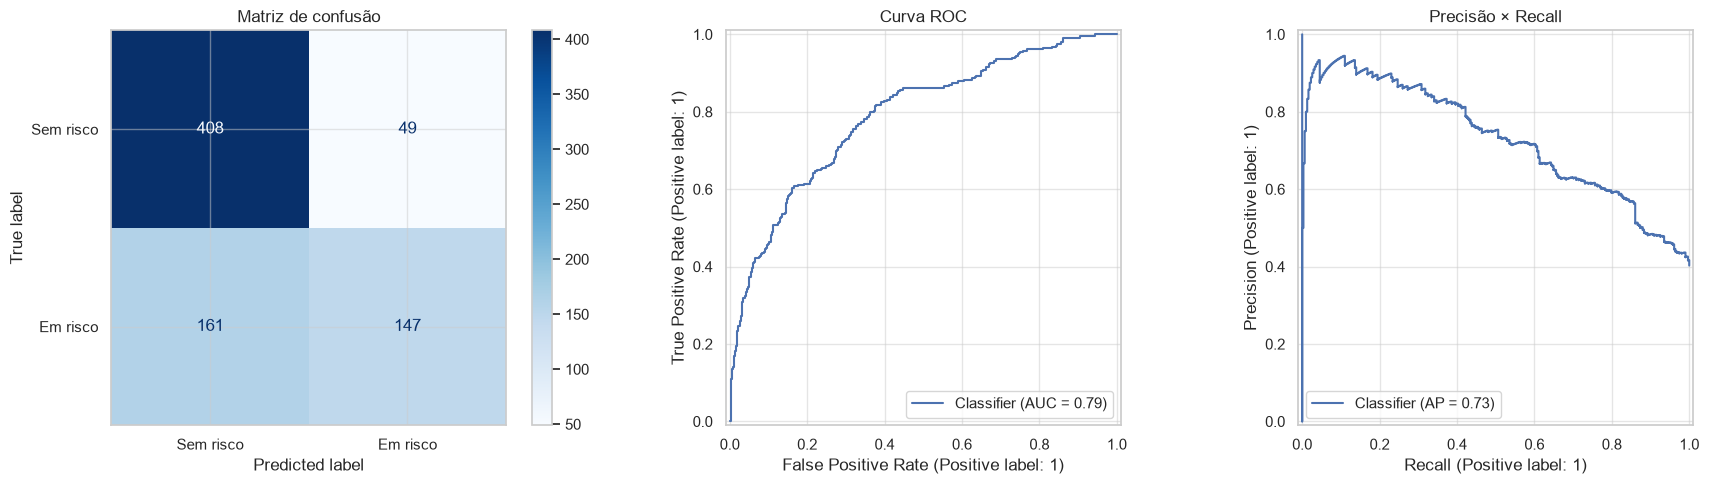

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_teste,
    display_labels=["Sem risco", "Em risco"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusão")

RocCurveDisplay.from_predictions(y_test, prob_teste, ax=axes[1])
axes[1].set_title("Curva ROC")

PrecisionRecallDisplay.from_predictions(y_test, prob_teste, ax=axes[2])
axes[2].set_title("Precisão × Recall")

plt.tight_layout()
plt.show()

## 6.6 Ajuste do limiar de decisão

O limiar padrão de 0,50 nem sempre é adequado. Em uma política preventiva, pode ser preferível aceitar mais falsos positivos para encontrar uma proporção maior dos alunos realmente em risco.

In [23]:
limiares = np.arange(0.10, 0.91, 0.05)
avaliacao_limiar = []

for limiar in limiares:
    pred_limiar = (prob_teste >= limiar).astype(int)

    avaliacao_limiar.append({
        "Limiar": limiar,
        "Precisão": precision_score(y_test, pred_limiar, zero_division=0),
        "Recall": recall_score(y_test, pred_limiar, zero_division=0),
        "F1": f1_score(y_test, pred_limiar, zero_division=0),
        "Alunos sinalizados": pred_limiar.sum()
    })

limiares_df = pd.DataFrame(avaliacao_limiar)
display(limiares_df)

melhor_limiar = limiares_df.loc[limiares_df["F1"].idxmax(), "Limiar"]
print("Limiar com maior F1:", round(float(melhor_limiar), 2))

,Limiar,Precisão,Recall,F1,Alunos sinalizados
0,0.100,0.407,1.000,0.579,756
1,0.150,0.434,0.981,0.602,696
2,0.200,0.463,0.945,0.621,629
3,0.250,0.487,0.886,0.628,561
4,0.300,0.584,0.828,0.685,437
5,0.350,0.618,0.731,0.670,364
6,0.400,0.660,0.649,0.655,303
7,0.450,0.722,0.565,0.634,241
8,0.500,0.750,0.477,0.583,196
9,0.550,0.817,0.406,0.542,153


Limiar com maior F1: 0.3


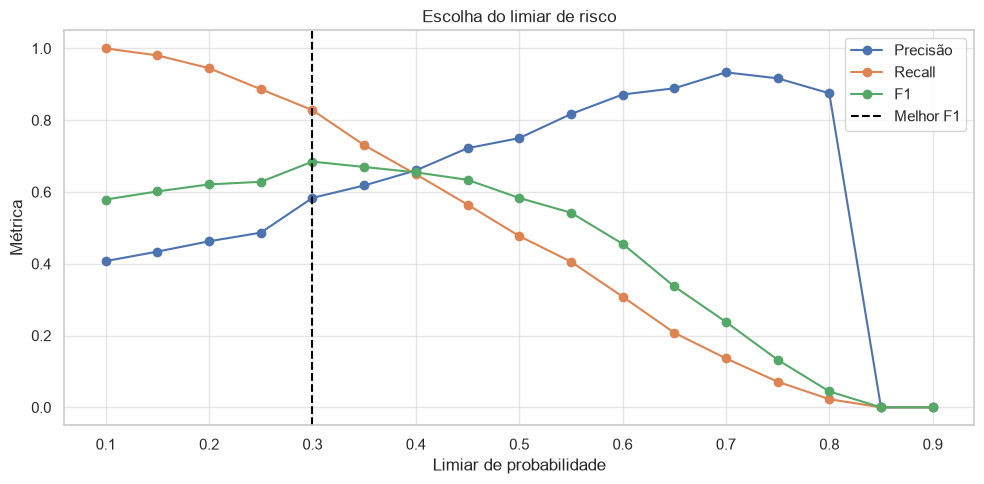

In [24]:
plt.figure(figsize=(10, 5))
for metrica in ["Precisão", "Recall", "F1"]:
    plt.plot(limiares_df["Limiar"], limiares_df[metrica], marker="o", label=metrica)

plt.axvline(melhor_limiar, ls="--", color="black", label="Melhor F1")
plt.title("Escolha do limiar de risco")
plt.xlabel("Limiar de probabilidade")
plt.ylabel("Métrica")
plt.legend()
plt.tight_layout()
plt.show()

## 6.7 Importância das variáveis

A importância por permutação é calculada sobre a base de teste e funciona com qualquer pipeline.

In [26]:
perm = permutation_importance(
    melhor_modelo,
    X_test,
    y_test,
    n_repeats=15,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importancias = pd.DataFrame({
    "Variavel": X_test.columns,
    "Importancia_Media": perm.importances_mean,
    "Desvio": perm.importances_std
}).sort_values("Importancia_Media", ascending=False)

display(importancias)

,Variavel,Importancia_Media,Desvio
8,IAN,0.107,0.014
14,IPV,0.031,0.006
3,Fase,0.026,0.003
1,Idade,0.016,0.002
7,INDE,0.013,0.008
2,Ano_Ingresso,0.006,0.001
15,Matematica,0.006,0.002
16,Portugues,0.004,0.001
12,IPS,0.004,0.001
10,IEG,0.003,0.002


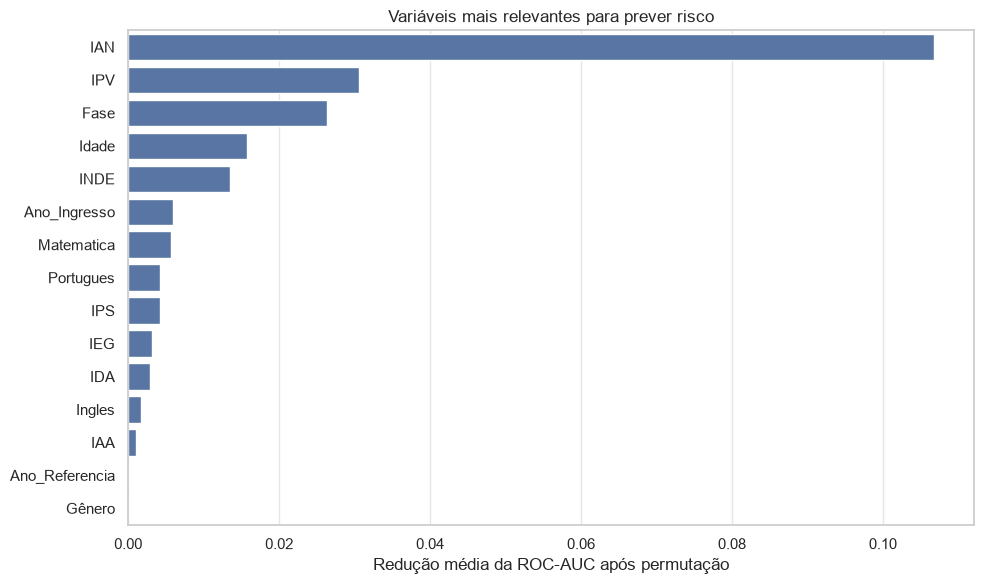

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importancias.head(15),
    x="Importancia_Media",
    y="Variavel"
)
plt.title("Variáveis mais relevantes para prever risco")
plt.xlabel("Redução média da ROC-AUC após permutação")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 6.8 Lista de alunos prioritários no conjunto de teste

Em uma entrega pública, prefira exibir somente o RA ou um identificador anonimizado.

In [28]:
prioridades = teste[["RA", "Ano_Referencia", "Fase", "INDE", "IAN", "IDA", "IEG", "IPS", "IPP", "IPV"]].copy()
prioridades["Probabilidade_Risco"] = prob_teste
prioridades["Risco_Real_2024"] = y_test.values
prioridades["Classificacao_Modelo"] = (
    prioridades["Probabilidade_Risco"] >= melhor_limiar
).astype(int)

prioridades = prioridades.sort_values("Probabilidade_Risco", ascending=False)

display(prioridades.head(20))

,RA,Ano_Referencia,Fase,INDE,IAN,IDA,IEG,IPS,IPP,IPV,Probabilidade_Risco,Risco_Real_2024,Classificacao_Modelo
1022,RA-514,2023,FASE 1,5.823,5.000,5.500,7.500,2.520,5.000,5.897,0.835,0,1
811,RA-131,2023,FASE 5,5.952,5.000,2.200,7.800,5.000,7.656,6.800,0.829,1,1
1069,RA-587,2023,FASE 1,6.032,5.000,2.700,7.000,7.520,6.458,6.720,0.820,1,1
659,RA-1071,2023,FASE 1,6.414,5.000,3.500,8.600,7.520,5.625,6.397,0.818,1,1
1176,RA-750,2023,ALFA,5.686,5.000,3.400,7.700,3.140,4.375,6.320,0.815,1,1
1229,RA-822,2023,ALFA,6.450,5.000,7.100,8.400,2.520,5.625,5.925,0.811,1,1
1246,RA-851,2023,ALFA,6.168,5.000,6.600,7.500,2.520,5.625,6.010,0.804,1,1
971,RA-422,2023,FASE 2,5.570,5.000,4.400,7.800,7.520,6.667,6.107,0.803,1,1
1173,RA-747,2023,FASE 1,6.026,5.000,3.100,8.000,3.140,6.042,6.940,0.794,1,1
1292,RA-911,2023,ALFA,5.595,5.000,3.400,6.700,2.520,5.312,7.010,0.792,1,1


## Pergunta 10 — Efetividade do programa

A análise combina:

- evolução das médias por ano;
- comparação por fase;
- evolução dos mesmos alunos;
- proporção de alunos que melhoraram.

In [ ]:
indicadores_programa = ["INDE", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "IAN"]

evolucao_programa = (
    dados.groupby("Ano")[indicadores_programa]
    .mean()
    .T
)

display(evolucao_programa)

plt.figure(figsize=(12, 6))
evolucao_programa.T.plot(marker="o", ax=plt.gca())
plt.title("Evolução média dos indicadores do programa")
plt.xlabel("Ano")
plt.ylabel("Média")
plt.ylim(0, 10)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# Variação individual média entre anos para os principais indicadores
variacoes = []

for a, b in [(2022, 2023), (2023, 2024)]:
    atual = dados[dados["Ano"] == a][["RA"] + indicadores_programa]
    futuro = dados[dados["Ano"] == b][["RA"] + indicadores_programa]

    pares = atual.merge(futuro, on="RA", suffixes=(f"_{a}", f"_{b}"))

    for indicador in indicadores_programa:
        delta = pares[f"{indicador}_{b}"] - pares[f"{indicador}_{a}"]

        variacoes.append({
            "Transicao": f"{a} → {b}",
            "Indicador": indicador,
            "Alunos_com_dados": delta.notna().sum(),
            "Variacao_media": delta.mean(),
            "%_melhorou": (delta > 0).mean() * 100
        })

variacoes_df = pd.DataFrame(variacoes)
display(variacoes_df)

# 7. Insights adicionais

## 7.1 Segmentação de risco por fase

In [ ]:
risco_fase = (
    base_modelo.groupby(["Ano_Referencia", "Fase"])
    .agg(
        Alunos=("RA", "count"),
        Taxa_Risco=("Risco_Defasagem", "mean")
    )
    .reset_index()
)

risco_fase["Taxa_Risco"] *= 100
display(risco_fase.sort_values("Taxa_Risco", ascending=False))

In [ ]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=risco_fase,
    x="Taxa_Risco",
    y="Fase",
    hue="Ano_Referencia",
    order=risco_fase.groupby("Fase")["Taxa_Risco"].mean().sort_values(ascending=False).index
)
plt.title("Taxa de defasagem futura por fase")
plt.xlabel("% de alunos em risco no ano seguinte")
plt.ylabel("Fase")
plt.tight_layout()
plt.show()

## 7.2 Indicadores por pedra

As pedras representam faixas do INDE e podem apoiar uma comunicação simples com gestores e educadores.

In [ ]:
pedra_resumo = (
    dados.groupby(["Ano", "Pedra_Atual"])
    .agg(
        Alunos=("RA", "count"),
        INDE_Medio=("INDE", "mean"),
        IDA_Medio=("IDA", "mean"),
        IEG_Medio=("IEG", "mean"),
        IPV_Medio=("IPV", "mean"),
        Defasagem_Media=("Defasagem", "mean")
    )
    .reset_index()
)

display(pedra_resumo)

# 8. Conclusões automáticas

As células abaixo imprimem um resumo quantitativo. A interpretação final deve considerar contexto pedagógico, tamanho das amostras e possíveis mudanças de metodologia entre os anos.

In [29]:
def tendencia(valor_inicial, valor_final, tolerancia=0.10):
    if pd.isna(valor_inicial) or pd.isna(valor_final):
        return "inconclusiva"
    delta = valor_final - valor_inicial
    if delta > tolerancia:
        return "melhora"
    if delta < -tolerancia:
        return "queda"
    return "estabilidade"


media_2022 = dados[dados["Ano"] == 2022].mean(numeric_only=True)
media_2024 = dados[dados["Ano"] == 2024].mean(numeric_only=True)

print("RESUMO EXECUTIVO")
print("-" * 70)

for indicador in ["INDE", "IDA", "IEG", "IAA", "IPS", "IPV", "IAN"]:
    print(
        f"{indicador}: {tendencia(media_2022.get(indicador), media_2024.get(indicador))} "
        f"({media_2022.get(indicador, np.nan):.2f} em 2022 → "
        f"{media_2024.get(indicador, np.nan):.2f} em 2024)"
    )

print()
print("Modelo:", melhor_nome)
print("ROC-AUC no teste temporal:", f"{roc_auc_score(y_test, prob_teste):.3f}")
print("Recall no limiar padrão:", f"{recall_score(y_test, pred_teste):.3f}")
print("Limiar sugerido pelo F1:", f"{melhor_limiar:.2f}")

print()
print("Principais variáveis preditivas:")
for _, linha in importancias.head(5).iterrows():
    print(f"- {linha['Variavel']}: {linha['Importancia_Media']:.4f}")

RESUMO EXECUTIVO
----------------------------------------------------------------------
INDE: melhora (7.04 em 2022 → 7.40 em 2024)
IDA: melhora (6.09 em 2022 → 6.35 em 2024)
IEG: queda (7.89 em 2022 → 7.37 em 2024)
IAA: estabilidade (8.27 em 2022 → 8.35 em 2024)
IPS: estabilidade (6.90 em 2022 → 6.83 em 2024)
IPV: melhora (7.25 em 2022 → 7.35 em 2024)
IAN: melhora (6.42 em 2022 → 7.68 em 2024)

Modelo: Random Forest
ROC-AUC no teste temporal: 0.788
Recall no limiar padrão: 0.477
Limiar sugerido pelo F1: 0.30

Principais variáveis preditivas:
- IAN: 0.1067
- IPV: 0.0306
- Fase: 0.0264
- Idade: 0.0158
- INDE: 0.0135


# 9. Recomendações para a Passos Mágicos

1. **Criar uma rotina de alerta preventivo:** atualizar mensal ou trimestralmente os indicadores e priorizar alunos com maior probabilidade de risco.
2. **Não usar o modelo como decisão automática:** a probabilidade deve apoiar, e não substituir, a avaliação de educadores, psicólogos e psicopedagogos.
3. **Priorizar recall:** em ações de prevenção, deixar um aluno em risco sem apoio tende a ser mais custoso do que avaliar um falso positivo.
4. **Monitorar grupos e fases críticas:** comparar taxa de risco, IDA, IEG e IPS por fase, turma e ano.
5. **Acompanhar discrepâncias entre IAA e IDA:** diferenças persistentes podem indicar necessidade de orientação, feedback ou apoio emocional.
6. **Registrar intervenções:** futuramente, adicionar ao dataset as ações realizadas e seus resultados para medir quais intervenções funcionam melhor.
7. **Monitorar justiça do modelo:** avaliar métricas por gênero, idade, fase e instituição para evitar desempenho desigual entre grupos.
8. **Revalidar o modelo anualmente:** mudanças no programa, instrumentos ou população podem reduzir a qualidade preditiva.

## Limitações

- IPP não está disponível em 2022, o que reduz sua utilização no primeiro período de treino.
- Os indicadores podem ter sofrido alterações metodológicas entre anos.
- Correlação não implica causalidade.
- O modelo prevê associação com risco, não determina que um indicador cause a defasagem.
- O tamanho das amostras longitudinais é menor que o total de registros.

# 10. Exportação do modelo e dos resultados

Os arquivos podem ser utilizados posteriormente na aplicação Streamlit.

In [31]:
import joblib

joblib.dump(melhor_modelo, "modelo_risco_defasagem.joblib")

metadados_modelo = {
    "modelo": melhor_nome,
    "features": features_modelo,
    "limiar": float(melhor_limiar),
    "roc_auc_teste": float(roc_auc_score(y_test, prob_teste))
}

joblib.dump(metadados_modelo, "metadados_modelo.joblib")
prioridades.to_csv("alunos_priorizados_teste.csv", index=False)
resultados_df.to_csv("comparacao_modelos.csv", index=False)
importancias.to_csv("importancia_variaveis.csv", index=False)
dados.to_csv("dados_tratados.csv",index=False)

print("Arquivos exportados:")
print("- modelo_risco_defasagem.joblib")
print("- metadados_modelo.joblib")
print("- alunos_priorizados_teste.csv")
print("- comparacao_modelos.csv")
print("- importancia_variaveis.csv")
print("- dados_tratados.csv")

Arquivos exportados:
- modelo_risco_defasagem.joblib
- metadados_modelo.joblib
- alunos_priorizados_teste.csv
- comparacao_modelos.csv
- importancia_variaveis.csv
- dados_tratados.csv
